# COCO localization analysis: Baseline vs Shared-Detach vs Shared-E2E

저장된 최종 checkpoint를 동일한 VOC validation split에서 다시 평가합니다. COCO 면적 구간(`small`, `medium`, `large`)별 AP와 IoU threshold별 AP를 통해 분류/탐지 여부와 별개로 박스 localization 품질을 비교합니다.

COCO 면적 구간: small < 32² px, medium 32²–96² px, large > 96² px.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from gt_aux.config import ExperimentConfig
from gt_aux.data import prepare_data, make_loaders
from gt_aux.eval import load_checkpoint

CONFIG = ExperimentConfig(ROOT, run_mode='smoke')
EXPERIMENTS = ['baseline', 'shared_detach', 'shared_e2e']
IOU_THRESHOLDS = [round(0.50 + 0.05 * index, 2) for index in range(10)]
RESULT_DIR = CONFIG.output_dir
print({'experiments': EXPERIMENTS, 'iou_thresholds': IOU_THRESHOLDS, 'device': str(CONFIG.device)})

d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'experiments': ['baseline', 'shared_detach', 'shared_e2e'], 'iou_thresholds': [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], 'device': 'cuda'}


In [2]:
BUNDLE = prepare_data(CONFIG)
_, VAL_LOADER = make_loaders(CONFIG, BUNDLE, CONFIG.seed)
print({'validation_images': len(BUNDLE.val_records), 'validation_batches': len(VAL_LOADER)})

VOC XML: 100%|██████████| 3750/3750 [00:01<00:00, 3137.96it/s]

Full split: train=3000 (9180 objects), val=750 (2530 objects)
Current run: train=400, val=100
{'validation_images': 100, 'validation_batches': 50}


In [3]:
@torch.inference_mode()
def collect_predictions(experiment):
    model, checkpoint, _ = load_checkpoint(CONFIG, BUNDLE, experiment)
    model.eval()
    predictions, targets = [], []
    try:
        for batch in tqdm(VAL_LOADER, desc=f'{experiment}: inference', leave=False):
            result = model(
                pixel_values=batch['pixel_values'].to(CONFIG.device, non_blocking=True),
                pixel_mask=batch['pixel_mask'].to(CONFIG.device, non_blocking=True),
                labels=None,
            )
            target_sizes = torch.stack([target['orig_size'] for target in batch['eval_targets']]).to(CONFIG.device)
            batch_predictions = BUNDLE.processor.post_process_object_detection(
                result['outputs'], threshold=0.0, target_sizes=target_sizes
            )
            predictions.extend([{key: value.detach().cpu() for key, value in item.items()} for item in batch_predictions])
            targets.extend([
                {'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()}
                for target in batch['eval_targets']
            ])
    finally:
        model.close()
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return checkpoint['epoch'], predictions, targets

def scalar(value):
    value = float(value)
    return None if value < 0 else value  # COCO reports -1 when an area bin has no GT

def score_localization(experiment, predictions, targets):
    # Default COCO thresholds: 0.50:0.05:0.95; includes area-specific AP.
    coco_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')
    coco_metric.update(predictions, targets)
    coco = coco_metric.compute()
    area_row = {
        'experiment': experiment,
        'AP': scalar(coco['map']),
        'AP@0.50': scalar(coco['map_50']),
        'AP@0.75': scalar(coco['map_75']),
        'AP_small': scalar(coco['map_small']),
        'AP_medium': scalar(coco['map_medium']),
        'AP_large': scalar(coco['map_large']),
    }
    curve_rows = []
    for threshold in IOU_THRESHOLDS:
        threshold_metric = MeanAveragePrecision(
            box_format='xyxy', iou_type='bbox', iou_thresholds=[threshold]
        )
        threshold_metric.update(predictions, targets)
        curve_rows.append({
            'experiment': experiment,
            'iou_threshold': threshold,
            'AP': scalar(threshold_metric.compute()['map']),
        })
    return area_row, curve_rows

In [4]:
area_rows, curve_rows = [], []
for experiment in EXPERIMENTS:
    checkpoint_epoch, predictions, targets = collect_predictions(experiment)
    area_row, experiment_curve_rows = score_localization(experiment, predictions, targets)
    area_row['checkpoint_epoch'] = checkpoint_epoch
    area_rows.append(area_row)
    curve_rows.extend(experiment_curve_rows)

area_df = pd.DataFrame(area_rows).set_index('experiment')
iou_curve_df = pd.DataFrame(curve_rows)
area_path = RESULT_DIR / f'coco_area_ap_{CONFIG.run_mode}.csv'
curve_path = RESULT_DIR / f'coco_iou_ap_curve_{CONFIG.run_mode}.csv'
area_df.to_csv(area_path)
iou_curve_df.to_csv(curve_path, index=False)
display(area_df)
print('Saved:', area_path)
print('Saved:', curve_path)

Loading weights: 100%|██████████| 545/545 [00:00<00:00, 17264.94it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

,AP,AP@0.50,AP@0.75,AP_small,AP_medium,AP_large,checkpoint_epoch
experiment,,,,,,,
baseline,0.087570,0.140646,0.090942,0.041103,0.076929,0.133518,7
shared_detach,0.070804,0.118766,0.071586,0.042266,0.073226,0.098229,7
shared_e2e,0.088933,0.141321,0.090989,0.061437,0.115618,0.119562,7


Saved: D:\gt-super\outputs\detr_gt_auxiliary\coco_area_ap_smoke.csv
Saved: D:\gt-super\outputs\detr_gt_auxiliary\coco_iou_ap_curve_smoke.csv


Saved: D:\gt-super\outputs\detr_gt_auxiliary\coco_localization_smoke.png


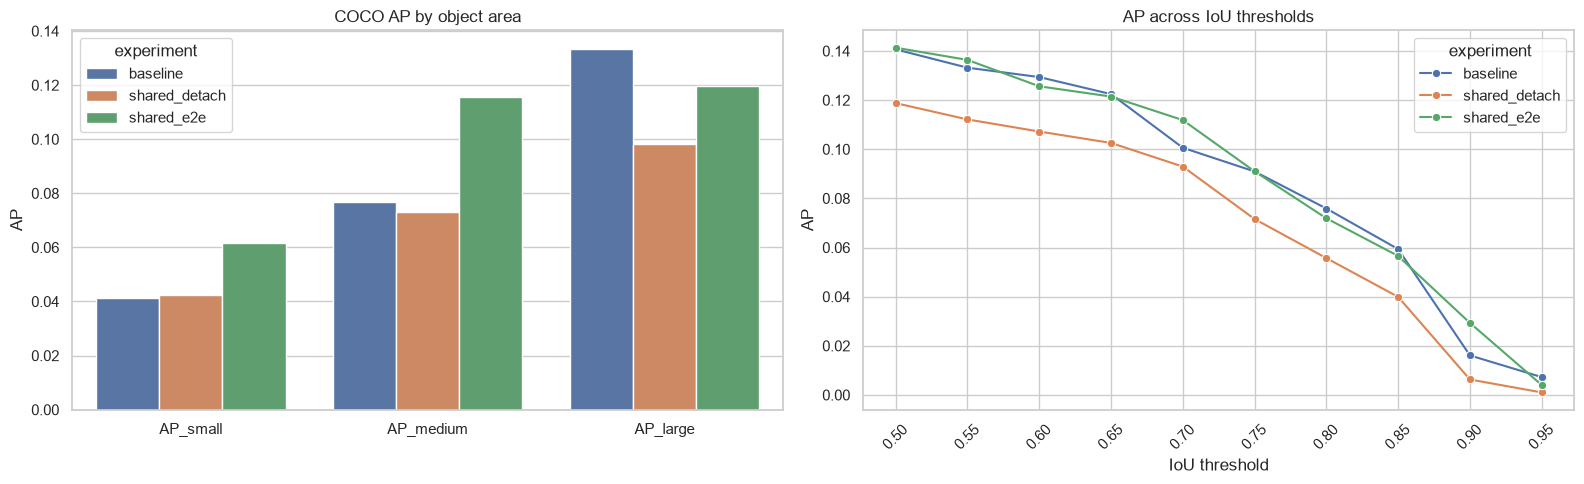

In [5]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

area_plot = area_df.reset_index().melt(
    id_vars='experiment',
    value_vars=['AP_small', 'AP_medium', 'AP_large'],
    var_name='area', value_name='ap_value',
)
sns.barplot(data=area_plot, x='area', y='ap_value', hue='experiment', ax=axes[0])
axes[0].set_title('COCO AP by object area')
axes[0].set_xlabel('')
axes[0].set_ylabel('AP')

sns.lineplot(data=iou_curve_df, x='iou_threshold', y='AP', hue='experiment', marker='o', ax=axes[1])
axes[1].set_title('AP across IoU thresholds')
axes[1].set_xlabel('IoU threshold')
axes[1].set_ylabel('AP')
axes[1].set_xticks(IOU_THRESHOLDS)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plot_path = RESULT_DIR / f'coco_localization_{CONFIG.run_mode}.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print('Saved:', plot_path)
plt.show()

## 해석 기준

- `AP@0.75`와 0.75 이상 IoU 구간의 곡선이 높을수록 box localization이 더 정밀합니다.
- `AP_small`만 낮으면 작은 물체의 feature resolution 또는 matching이 병목일 가능성이 큽니다.
- `AP@0.50`은 비슷하지만 고 IoU 구간에서 낮다면 물체는 찾지만 box 위치/크기 오차가 큰 경우입니다.
- 이 결과는 seed 1개에 대한 비교이므로, 결론을 확정하려면 여러 seed 평균과 표준편차를 비교해야 합니다.